In [31]:
from math import ceil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import pyplot as mp
from pandas import DatetimeIndex
from pandas import DataFrame
from pathlib import Path

In [32]:
def gaussian(width: float, height: float):
    """
    Returns a Gaussian function with the provided height and width 
    @param width: the desired width of the curve
    @param height: the desired height of the curve
    @return: 
    """
    sig = width / 6
    mu = 0
    x = np.linspace((-4*sig), 4*sig, ceil(width))
    a = height / (0.3989 / sig)
    return (
        a / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

def anomaly(dt: DatetimeIndex, dy: float) -> DataFrame:
    """
    Creates an anomalous change in temperature
    @param dt: the time interval over which the anomaly occurs
    @param dy: the temperature variation in degrees Celsius which characterizes the anomaly
    @return: 
    """
    width = dt.shape[0]
    height = dy
    curve = gaussian(width, height)
    anomaly = pd.DataFrame(data=curve, index=dt, columns=["TL"])
    anomaly.index.name = "time"
    return anomaly

<AxesSubplot: xlabel='time'>

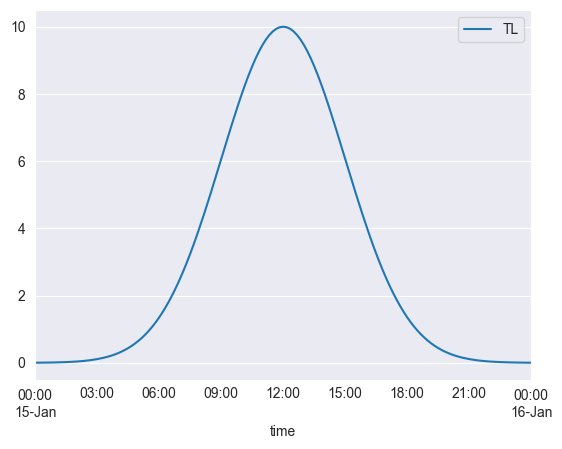

In [33]:
dt = pd.date_range(start='2020-01-15T00:00:00',
                  end='2020-01-16T00:00:00',
                  freq="10T"
                  )

df = anomaly(dt, 10.0)
df.plot()

In [34]:
frames = [
    pd.read_csv(Path.cwd().joinpath('data/processed/zamg_vienna.csv'), index_col='time', parse_dates=True),
]
df = pd.concat(frames)

,DD,FFAM,P,RF,RR,SO,TL,DD_sin,DD_cos,RR_norm
time,,,,,,,,,,
2020-01-01 00:00:00,302.0,3.2,1012.4,60.0,0.0,0.0,5.0,-0.848048,0.529919,0.0
2020-01-01 00:10:00,293.0,3.7,1012.5,60.0,0.0,0.0,5.0,-0.920505,0.390731,0.0
2020-01-01 00:20:00,291.0,3.7,1012.5,61.0,0.0,0.0,4.9,-0.933580,0.358368,0.0
2020-01-01 00:30:00,296.0,3.3,1012.5,61.0,0.0,0.0,4.9,-0.898794,0.438371,0.0
2020-01-01 00:40:00,293.0,3.7,1012.6,60.0,0.0,0.0,4.9,-0.920505,0.390731,0.0
...,...,...,...,...,...,...,...,...,...,...
2020-01-02 23:20:00,165.0,1.7,1007.0,83.0,0.0,0.0,0.4,0.258819,-0.965926,0.0
2020-01-02 23:30:00,160.0,1.5,1006.9,83.0,0.0,0.0,0.4,0.342020,-0.939693,0.0
2020-01-02 23:40:00,185.0,1.6,1006.9,84.0,0.0,0.0,0.3,-0.087156,-0.996195,0.0


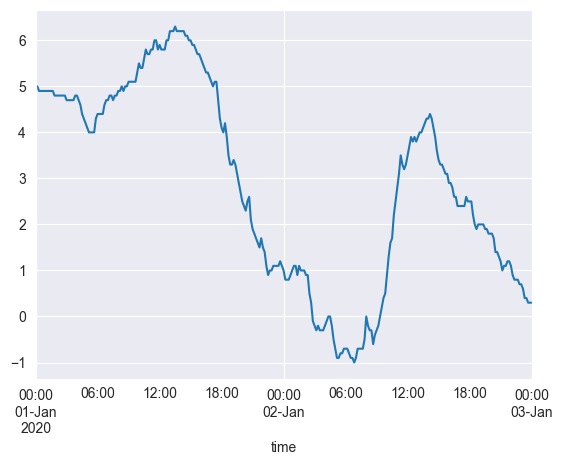

In [35]:
start = '2020-01-01 00:00:00'
end = '2020-01-03 00:00:00'

gap = slice(start, end)

baseline = df.loc[gap]
baseline['TL'].plot()
baseline

In [40]:
dt1 = pd.date_range(start='2020-01-01 06:00:00',
                  end='2020-01-02 00:00:00',
                  freq="10T"
                  )
anomaly1 = anomaly(dt1, -5.0)

dt2 = pd.date_range(start='2020-01-02 00:00:00',
                  end='2020-01-02 18:00:00',
                  freq="10T"
                  )
anomaly2 = anomaly(dt2, 5.0)

result = baseline.add(anomaly1, fill_value=0)
result = result.add(anomaly2, fill_value=0)
result


,DD,DD_cos,DD_sin,FFAM,P,RF,RR,RR_norm,SO,TL
time,,,,,,,,,,
2020-01-01 00:00:00,302.0,0.529919,-0.848048,3.2,1012.4,60.0,0.0,0.0,0.0,5.0
2020-01-01 00:10:00,293.0,0.390731,-0.920505,3.7,1012.5,60.0,0.0,0.0,0.0,5.0
2020-01-01 00:20:00,291.0,0.358368,-0.933580,3.7,1012.5,61.0,0.0,0.0,0.0,4.9
2020-01-01 00:30:00,296.0,0.438371,-0.898794,3.3,1012.5,61.0,0.0,0.0,0.0,4.9
2020-01-01 00:40:00,293.0,0.390731,-0.920505,3.7,1012.6,60.0,0.0,0.0,0.0,4.9
...,...,...,...,...,...,...,...,...,...,...
2020-01-02 23:20:00,165.0,-0.965926,0.258819,1.7,1007.0,83.0,0.0,0.0,0.0,0.4
2020-01-02 23:30:00,160.0,-0.939693,0.342020,1.5,1006.9,83.0,0.0,0.0,0.0,0.4
2020-01-02 23:40:00,185.0,-0.996195,-0.087156,1.6,1006.9,84.0,0.0,0.0,0.0,0.3


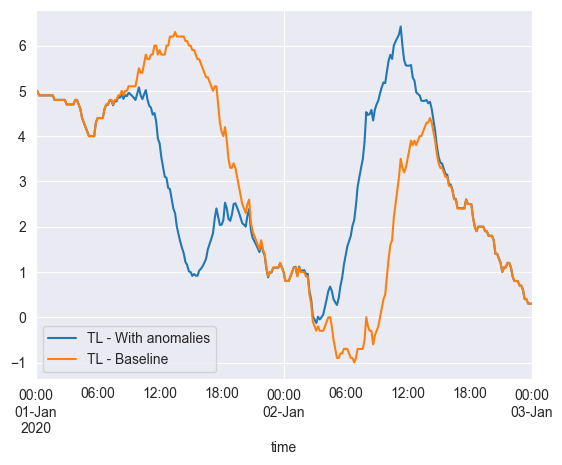

In [41]:
result['TL'].plot()
baseline['TL'].plot()
plt.legend(["TL - With anomalies", "TL - Baseline"])
plt.show()

In [42]:
result.to_csv(Path.cwd().joinpath('data/processed/zamg_vienna_anomalies.csv'))